In [212]:
import sys, os, torch, pdb
import numpy as np
import torch.nn as nn
from IPython.display import Image

sys.path.append('../../')
sys.path.append('../../../')
cwd = os.getcwd()

from Modules.helpers.performance.density.plotting_loss_running_min import plot_running_min_val_loss_broken_x_log_lst
from Modules.helpers.performance.density.plotting_final_loss import plot_final_loss_lst
from Modules.helpers.performance.plotting_timings import plot_total_run_times_lst

from Modules.helpers.performance.diffusion.plotting_mse_running_min import plot_running_min_MSE_diff_loss_broken_x_log_lst
from Modules.helpers.performance.diffusion.plotting_final_mse import plot_diff_mse_lst
from Modules.helpers.performance.diffusion.gif_model_loss import  save_gif_running_min_MSE_diff_loss_broken_x_log

from Modules.helpers.performance.growth.plotting_mse_running_min_growth import plot_running_min_MSE_grow_loss_broken_x_log_lst
from Modules.helpers.performance.growth.plot_final_mse_grow import plot_grow_mse_lst
from Modules.helpers.performance.growth.gif_model_loss_growth import  save_gif_running_min_MSE_grow_loss_broken_x_log

from Modules.helpers.real_space_plotter import symbolic_from_function, plot_eval_D_multi, plot_eval_G_multi
from Modules.helpers.performance.gif_DG_over_epochs import save_gif_running_min_MSE_diff_and_grow_broken_x_log


from Modules.helpers.plotting_profiles import plot_initial_condition_2d, plot_eval2
from file_finder import (paths_to_df,
                         find_data_obj_files, 
                         condense_df,
                         print_path_components)
from Modules.helpers.parse import dictToPath

# Add to main
from data.python.Modules.dataClass import OriginalData, Data
from binn.python.Modules.Models.BuildBINNs_2D import BINN_2d,u_MLP, D_MLP, G_MLP, pde_loss_without_bc_2d, data_loss_MSE, generate_random_inputs_2d
from binn.python.Modules.Utils.ModelWrapper_1D import ModelWrapper


ext  = "dataObj/original?_1/DValue_0.024720000000000002/rValue_1.536/gamma_0.2/K_1700.0/xNum_38/tNum_5/originalDataObj.npy"
data_orig_obj_FKPP = np.load(os.path.join('../../../', ext),allow_pickle=True).item(0)

## Choose and load data

In [213]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1
inital_path = os.path.join('../../../', "DataObj")

# ==================== Display available data objects ====================
data_df = paths_to_df(find_data_obj_files(start_dir = inital_path,
                                           target_filename="data_obj.npy"))
#data_df

In [214]:
x1Num = 11
x2Num = 11
tNum = 9
gamma = 0
noise_percent_list = [5]#[0.5, 1, 2, 5]#, 10]  
IC_label = "cosFlat0.5"
diff_label= "const"
seed = 0
results_dict = {}
data_info_dic = {}

grow_labels = ["linear"]#, "quadratic", "exp"]

data_obj_dic = {}
for grow_label in grow_labels:
    # =================== Choose data object ====================
    data_info = {
            "dataX1num": x1Num,
            "dataX2num": x2Num,
            "dataTnum": tNum,
            "dataK": K,
            "dataICLabel": IC_label,
            "dataDiffLabel": diff_label,
            "dataGrowLabel": grow_label,
            "dataGamma": gamma,
            "dataNoisePercent": noise_percent_list[0],
            "dataNoiseSeed": seed
        }
    data_df_updated = condense_df(data_df, data_info)
    data_file_path = data_df_updated["full_path"][0]
    data_obj = np.load(data_file_path,allow_pickle=True).item()
    data_obj_dic[grow_label] = data_obj
# data_df_updated

MSE between u and u_clean: 0.11268687078532247
ABS between u and u_clean [cells]: 10.83264292484585
ABS (%) between u and u_clean (on |u_clean| ≥ 1.000e-06): 4.999987070361316


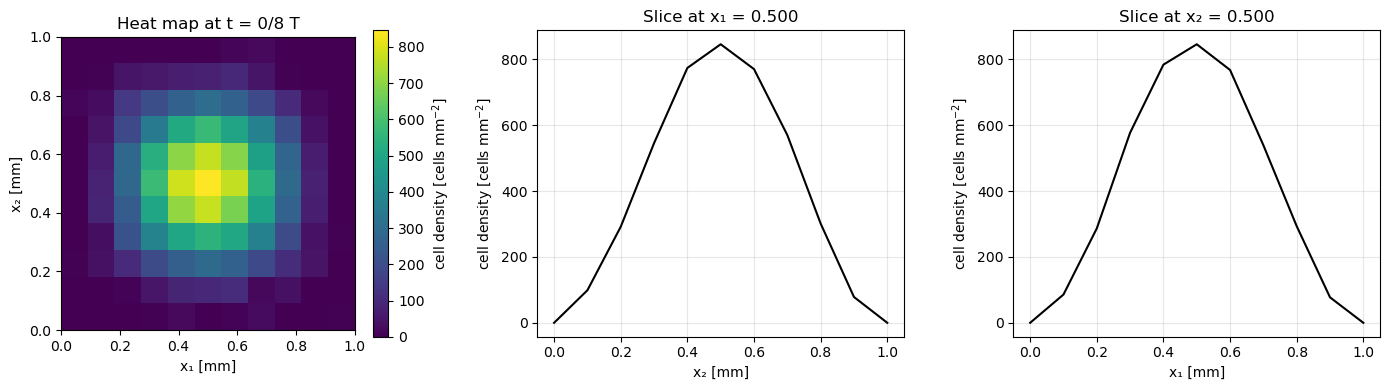

In [215]:
# ==================== Load data object ====================
data_obj_orig = np.load(data_file_path,allow_pickle=True).item()
plot_initial_condition_2d(data_obj_orig)

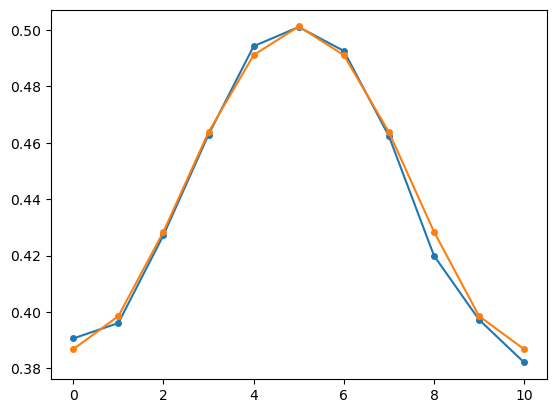

In [216]:
import matplotlib.pyplot as plt
plt.plot(data_obj_orig.u[5,:,6], marker='o', label='Noisy Data', markersize=4)
plt.plot(data_obj_orig.u_clean[5,:,6], marker='o', label='Noisy Data', markersize=4)
#plt.ylim(np.min(data_obj_orig.u_clean), np.max(data_obj_orig.u_clean))

In [217]:
np.mean((data_obj_orig.u_clean*1700 - data_obj_orig.u*1700 )**2)


191.56768033504818

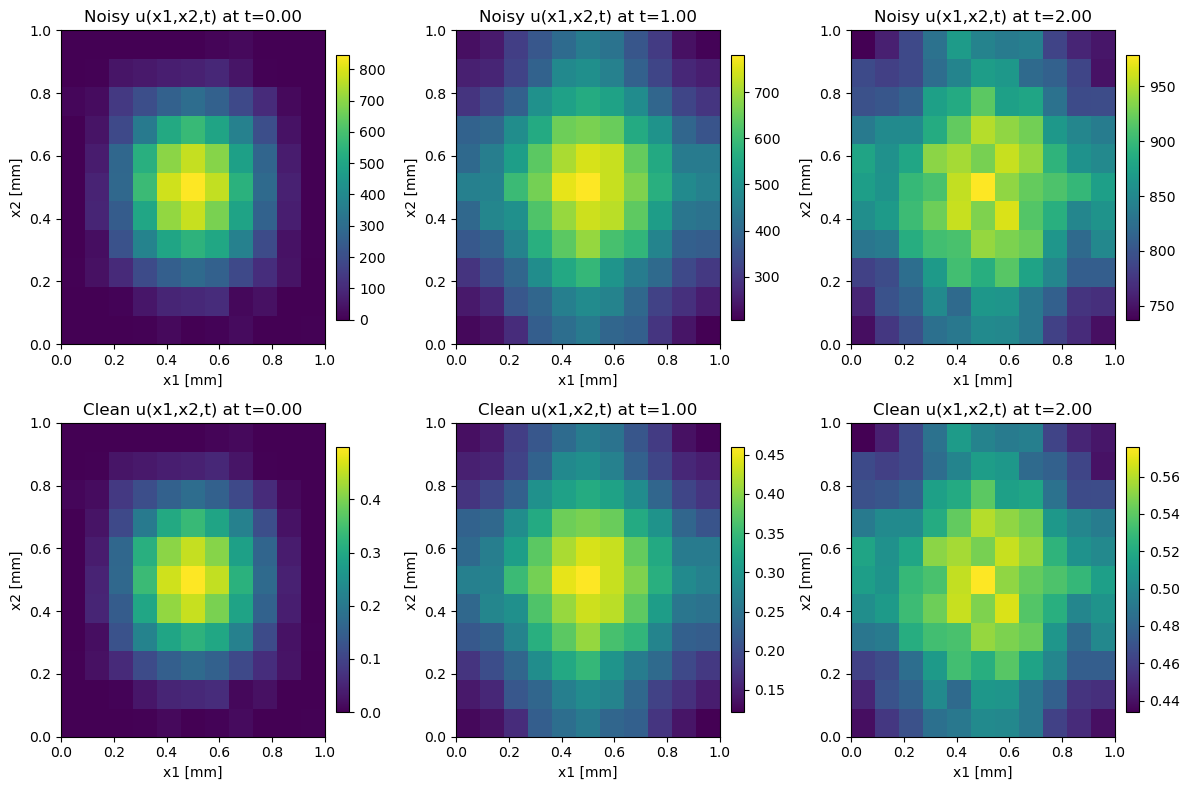

In [218]:
from data.python.Modules.dataClass import plot_2d_data
plot_2d_data(x1 = data_obj_orig.x1,  x2 = data_obj_orig.x2, t = data_obj_orig.t, u = data_obj_orig.u*1700, u_clean = data_obj_orig.u)

## Choose and load binn model

In [219]:
binn_df = paths_to_df(find_data_obj_files(start_dir='../../../', target_filename="binnModel0.pth"))
binn_batch_size = x1Num*x2Num
binn_rel_update_thresh = 0.05
binn_rel_save_thresh = 0.05
binn_lr = 1e-3
binn_split_seed = 0
noise_percent = noise_percent_list[0]

fixed_filters = {
        "dataX1num": x1Num,
        "dataX2num": x2Num,
        "dataTnum": tNum,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": noise_percent,
        "dataNoiseSeed": seed,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelSaveThresh": binn_rel_save_thresh
        }
binn_df1 = condense_df(binn_df, fixed_filters)
binn_df1

,full_path,dataX1num,dataX2num,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,...,denoiseLR,denoiseBatchSize,denoiseRelUpdateThresh,denoiseRelSaveThresh,denoiseES,denoiseManualTermination,denoiseModelLabel,binnInitializeDenoiseBool,twoStepBool,combineDenoise
0,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
1,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
2,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
3,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
4,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
5,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
6,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
7,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
8,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None
9,../../../binn/dataX1num_11/dataX2num_11/dataTn...,11,11,9,1,cosFlat0.5,const,linear,0,5,...,0.001,38,0.05,0.05,500,None,0,1,0,None


In [220]:
binnVF = 0.2
binn_model_num = 0
D_one_param_bool = False
binnInitializeDenoiseBool = 0
two_step_bool = 0
binnDevice = "cpu"
BNdataLossFuncLabel = "MSE"
BCbool = 0
numPDEsamples = 100
combineDenoise = None
allConstraints = True

# =============== USER input ==================
binn_ES_list = [2000, 5000]#, 5000]#, 2000]#, 1000, 2000]#, 1000, 2000]
binnSplitSeeds = [0,1,2]#, 1]#,1,2]#,1,2]#,1,2]#,2]#, 1, 2]
u_NN = 64
D_NN = 4 
G_NN = 4
binn_models_by_noise = {}
binn_models_dics = {}
# ==============================================
binn_ext = {
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": "random",
        "binnTVsplitSeed": binnSplitSeeds[0],  
        "binnUsize": u_NN,              
        "binnDsize": D_NN,         
        "binnGsize": G_NN,   
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "allConstraints": allConstraints,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
        "BCbool": BCbool,
        "numPDEsamples": numPDEsamples,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
        "binnES": binn_ES_list[0],
        "binnModelLabel":          binn_model_num,
}
binn_info = data_info.copy()
for ES in binn_ES_list:
    print(f"Loading BINN models for ES = {ES}...")
    binn_models_dics[ES] = {}
    binn_ext["binnES"] = ES
    for grow_label in grow_labels:
        binn_info["dataGrowLabel"] = grow_label
        binn_models_dics[ES][grow_label] = {}
        for binnSplitSeed in binnSplitSeeds:
            # Update model parameters
            binn_ext["binnES"] = ES
            binn_ext["binnTVsplitSeed"] = binnSplitSeed
            binn_info.update(binn_ext)
            path_to_models = os.path.join("../../../binn", dictToPath(binn_info))
            file_path = os.path.join(path_to_models, f'binnModel{binn_model_num}.pth')
            binn_loaded = torch.load(file_path, weights_only=False)
            binn_loaded.load_best_val()
            binn_models_dics[ES][grow_label][binnSplitSeed] = binn_loaded

# Store all models for this ES

diff_test = binn_models_dics[binn_ES_list[0]][grow_labels[0]][0].model.diffusion
total_p = sum(p.numel() for p in diff_test.parameters())
print(f"Number of parameters for NN  = {total_p}\n")

Loading BINN models for ES = 2000...
Loading BINN models for ES = 5000...
Number of parameters for NN  = 53



/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/density/plotting_loss_running_min.py:222: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/density/plotting_loss_running_min.py:385: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/binn/NNu64_linear_dataGamma0.png


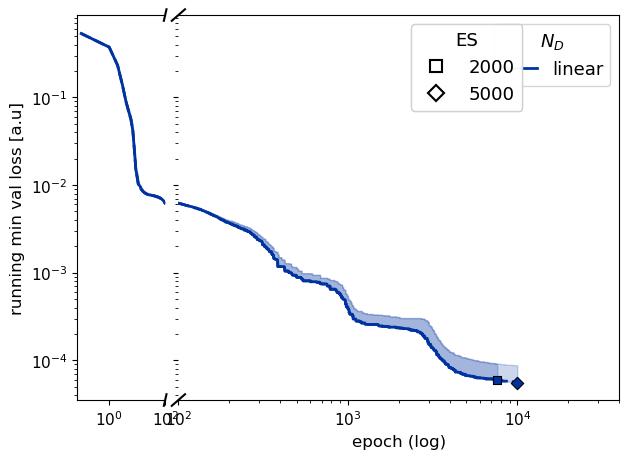

All x-axis labels found (ordered): ['linear']
saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/binn/NNu64_linear_dataGamma0_loss_bars.png


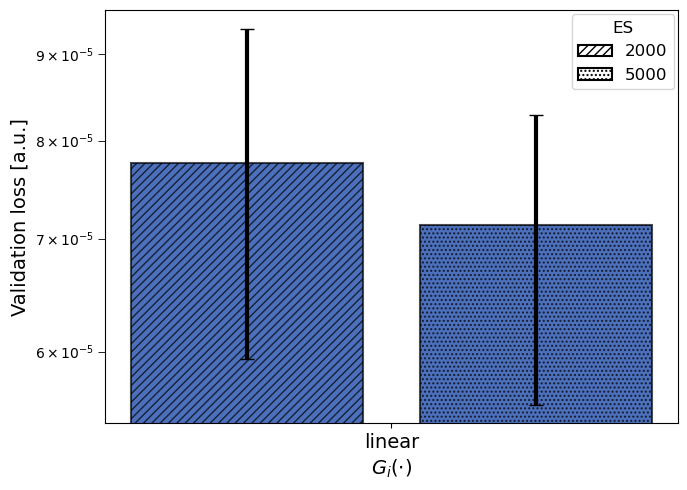

In [229]:
binn_plot = 1
binn_plot_density = True
binn_plot_times = 1

blue_colors = [
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8"             
]#[::-1]


linestyles = ['-']*5
marker_styles = ['o']*5

def form_labels_binn(models_dics):
    return [f"{key}" for key in models_dics.keys()]

ES_chosen = binn_ES_list[0]
binn_models_dics_chosen_ES = binn_models_dics[ES_chosen]
labels = form_labels_binn(binn_models_dics_chosen_ES)


model_keys = list(binn_models_dics_chosen_ES.keys())


plot_params = {
    key: [blue_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}
  

binn_models_by_ES = []
for binn_models_dics_item in list(binn_models_dics.values()):
    binn_models_by_ES.append(binn_models_dics_item)


name_intro = f"../../pngs/1D/Case13/plot_varyD/diff_{diff_label}/binn"
os.makedirs(name_intro, exist_ok=True)
name_full = os.path.join(name_intro, f'NNu64_{grow_label}_dataGamma{gamma}.png')
es_entries = [(binn_ES_list[0], "s")]
es_entries += [
    (binn_ES_list[1], "D")]#,

#     (binn_ES_list[2], "^")
# ]

plot_settings = {
    'name': name_full,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (1,1),
        "loc_upd": (0.8, 1),
        'fontsize': 13,
        'ncols': 1,
        "title": r"$N_D$"
    },
    'xaxis': {
        'min': 0,
        'max': 4e4,
        'break': 1e2
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": es_entries
}




if binn_plot:  
    plot_running_min_val_loss_broken_x_log_lst(models_dics_list =binn_models_by_ES,
                                             plot_params=plot_params,
                                             plot_settings=plot_settings)
    name_full = os.path.join(name_intro, f'NNu64_{grow_label}_dataGamma{gamma}_loss_bars.png')
    plot_final_loss_lst(binn_models_by_ES,
                                plot_params=plot_params,
                                label_list=[f"{ES}" for ES in binn_ES_list],
                                 name=name_full,
                                 bbox_to_anchor=(0.8,1.01),
                                 y_label="Validation loss [a.u.]",
                                 legend_size=12,
                                 figsize=(7, 5),
                                hatch_patterns=(
                                    "////",  "....", "ooo", "***"),
                                 x_label=r"$G_i(\cdot)$")



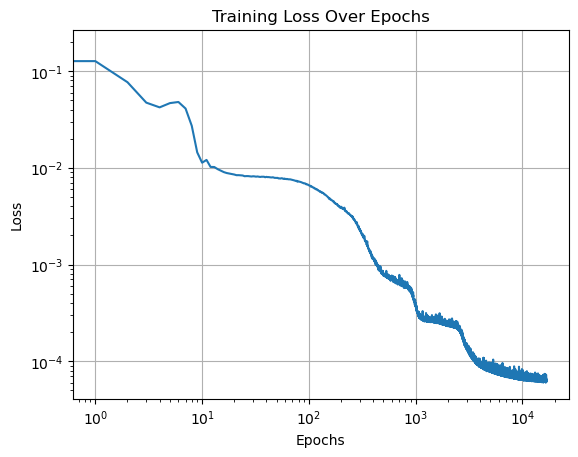

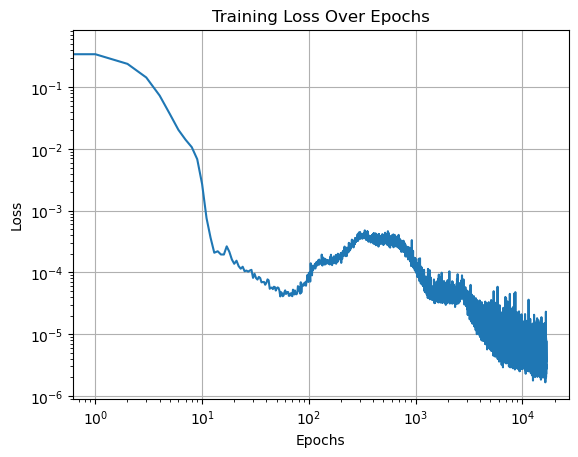

In [222]:
plt.plot(binn_loaded.train_data_loss_list)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.show()


plt.plot(binn_loaded.train_pde_loss_list)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.show()

All x-axis labels found (ordered): ['linear']
saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/binn/NNu64_linear_dataGamma0_times.png


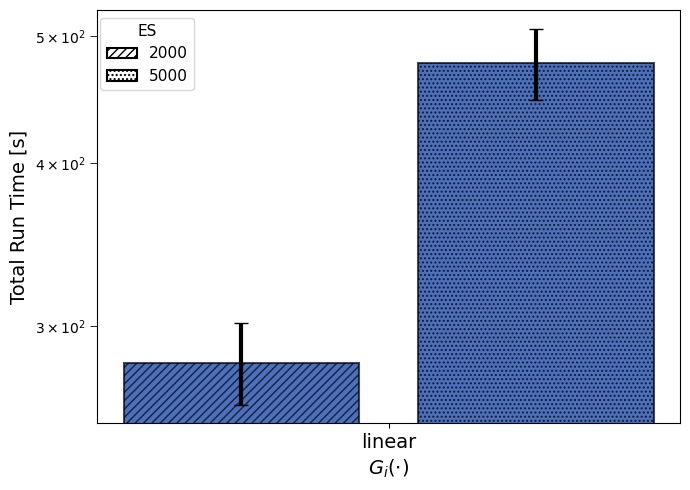

In [223]:
if binn_plot_times:
    name_full = os.path.join(name_intro, f'NNu64_{grow_label}_dataGamma{gamma}_times.png')
    plot_total_run_times_lst(models_dics_list=binn_models_by_ES,
                                plot_params=plot_params,
                                label_list=[f"{ES}" for ES in binn_ES_list],
                                legend_pos=(0.18, 1),
                                legend_fontsize=11,
                                 name=name_full,
                                hatch_patterns=(
                                    "////",  "....", "ooo", "***"),
                                 x_label = r"$G_i(\cdot)$")



/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/diffusion/plotting_mse_running_min.py:242: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/diffusion/plotting_mse_running_min.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/diff/NNu64_linear_dataGamma0_D_mse.png


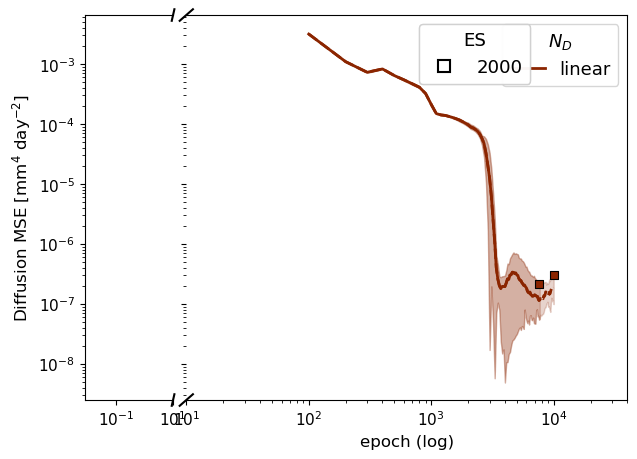

/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/growth/plotting_mse_running_min_growth.py:242: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/growth/plotting_mse_running_min_growth.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/grow/NNu64_linear_dataGamma0_G_mse.png


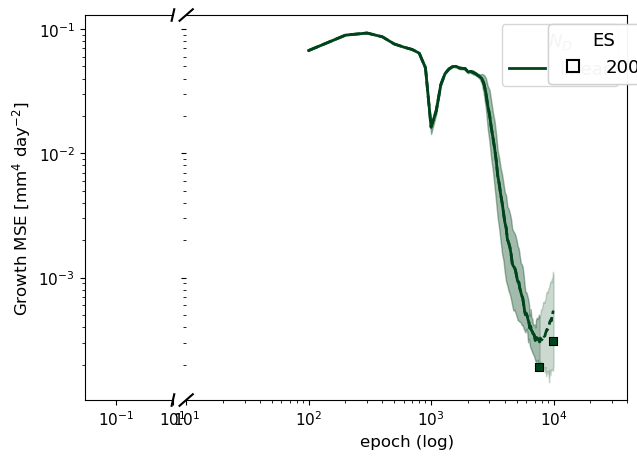

In [224]:
D_colors = [
    "#8B2500",  # Burnt Orange – deep and bold
    "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
    "#FDB863",  # Soft Tangerine – warm midtone
    "#FDD9B5",  # Peach – light orange-beige, easy on the eyes
    "#FFF1E0",  # Cream – very light accent, background-compatible
]

G_colors = [
    "#00441B",  # Deep Forest Green – dark, bold
    "#1A9850",  # Vivid Green – saturated, classic "plot green"
    "#66C2A4",  # Soft Mint Green – pleasant midtone
    "#B2E2E2",  # Light Aqua – soft, readable
    "#E5F5F9",  # Very Pale Greenish-White – background-compatible
]

u_colors = [
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8"             
]#[:len(widths)]
                               # hatch by depth


name_intro_D = f"../../pngs/1D/Case13/plot_varyD/diff_{diff_label}/diff"
name_intro_G = f"../../pngs/1D/Case13/plot_varyD/diff_{diff_label}/grow"
name_full_D = os.path.join(name_intro_D, f'NNu64_{grow_label}_dataGamma{gamma}_D_mse.png')
os.makedirs(name_intro_D, exist_ok=True)
name_full_G = os.path.join(name_intro_G, f'NNu64_{grow_label}_dataGamma{gamma}_G_mse.png')
os.makedirs(name_intro_G, exist_ok=True)

plot_params_D = {
    key: [D_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}

plot_params_G = {
    key: [G_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}

plot_settings_D = {
    'name': name_full_D,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (1,1),
        'loc_upd': (0.8, 1),
        'fontsize': 13,
        'ncols': 1,
        'title': r"$N_D$"
    },
    'xaxis': {
        'min': 0,
        'max': 4e4,
        'break': 1e1
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": es_entries
}


plot_settings_G = {
    'name': name_full_G,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (1,1),
        'loc_upd': (0.8, 1),
        'fontsize': 13,
        'ncols': 1,
        'title': r"$N_D$"
    },
    'xaxis': {
        'min': 0,
        'max': 4e4,
        'break': 1e1
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": es_entries
}


  
_ = plot_running_min_MSE_diff_loss_broken_x_log_lst(models_dics_list=binn_models_by_ES,
                                            plot_params=plot_params_D,
                                            plot_settings=plot_settings_D)




_ = plot_running_min_MSE_grow_loss_broken_x_log_lst(models_dics_list=binn_models_by_ES,
                                            plot_params=plot_params_G,
                                            plot_settings=plot_settings_G)

Scale factor k = 1.02
MSE over [0, 1]: 2.444313599999991e-07
Mean absolute percentage error over [0, 1]: 1.9999999999999962
Scale factor k = 1.03
MSE over [0, 1]: 5.499705600000029e-07
Mean absolute percentage error over [0, 1]: 3.000000000000008
All x-axis labels found (ordered): ['linear']
saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/diff/NNu64_linear_dataGamma0_D_loss_bars.png


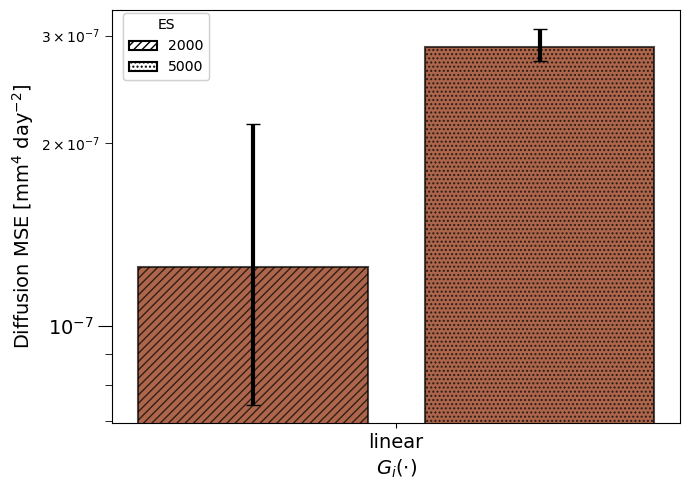

All x-axis labels found (ordered): ['linear']
saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/grow/NNu64_linear_dataGamma0_G_loss_bars.png


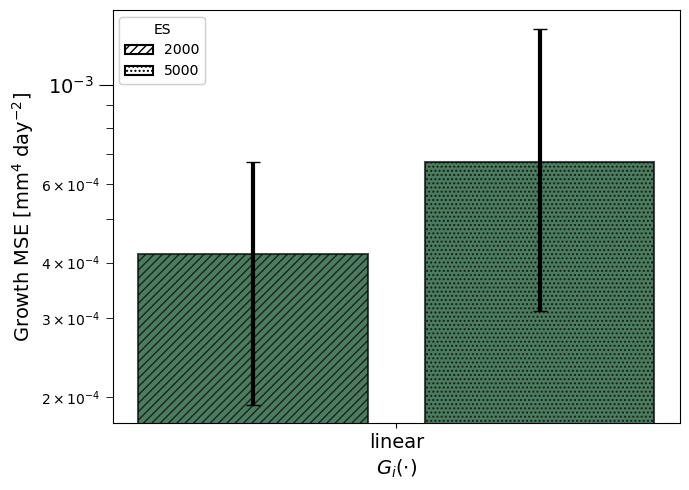

In [225]:
import numpy as np

def make_C_from_D(D, beta, n_points=1001):
    """
    Create a new function C(u) = k * D(u) such that the
    mean absolute percentage error is beta (%), and print
    MSE and absolute percentage error for u in [0, 1].

    Parameters
    ----------
    D : callable
        Original function D(u).
    beta : float
        Target absolute percentage error in percent.
    n_points : int
        Number of points in [0, 1] to use for error calculation.

    Returns
    -------
    C : callable
        New scaled function C(u) = k * D(u).
    """
    # Scale factor so that APE = beta (%)
    k = 1.0 + beta / 100.0  # could also use 1 - beta/100.0

    def C(u):
        return k * D(u)

    # Sample u in [0, 1]
    u = np.linspace(0.0, 1.0, n_points)
    D_vals = np.array([D(ui) for ui in u])
    C_vals = k * D_vals

    # Mean Squared Error over [0, 1]
    mse = np.mean((C_vals - D_vals) ** 2)

    # Mean Absolute Percentage Error (%)
    # avoid division by zero if D(u) = 0 somewhere
    mask = D_vals != 0
    if np.any(mask):
        ape = np.mean(
            np.abs((C_vals[mask] - D_vals[mask]) / D_vals[mask])
        ) * 100.0
    else:
        ape = np.nan  # undefined if D(u) is identically zero

    print(f"Scale factor k = {k}")
    print(f"MSE over [0, 1]: {mse}")
    print(f"Mean absolute percentage error over [0, 1]: {ape}")

    return C, mse, ape

# From file path info contstruct true D

# From file path info contstruct true D
# --- Diffusion models ---
diffusion_models = {
    "const":     (lambda u, a: np.full_like(u, a), [0.02472]),
    "linear":    (lambda u, a, b: a + b * u,         [0.015, 0.06]),
    "quadratic": (lambda u, a, b: a + b * u**2,      [0.01, 0.044]),
    "exp":       (lambda u, a, b, c: a + b * (1 - sp.exp(-c * u)), [0.003, 0.095, 2.5])
}

# --- Growth models ---
growth_models = {
    "const":     (lambda u, a: np.full_like(u, a) / 2,          [1.3]),
    "linear":    (lambda u, a, b: (a + b * u) / 2,              [2.4, -3]),
    "quadratic": (lambda u, a, b: (a + b * u**2) / 2,           [2.1, -0.29]),
    "exp":       (lambda u, a, b, c: (a + b * (1 - sp.exp(-c * u))) / 2, [0.7, 1.3, -4]),
    "zero":      (lambda u, _: np.full_like(u, 0.0),            [0])
}

# --- Function dispatch ---
diff_func, theta_D = diffusion_models[diff_label]
grow_func, theta_G = growth_models[grow_label]

def diffusion_func(u):
    return diff_func(u, *theta_D)


    #print("check PE:", np.mean(100*np.abs(alpha - D_true)/D_true))
mses = []
beta_list = [2,3]
for beta in beta_list:
    _,mse, ape =  make_C_from_D(diffusion_func, beta=beta)
    mses.append(mse)



name_full_D = os.path.join(name_intro_D, f'NNu64_{grow_label}_dataGamma{gamma}_D_loss_bars.png')
name_full_G = os.path.join(name_intro_G, f'NNu64_{grow_label}_dataGamma{gamma}_G_loss_bars.png')

plot_diff_mse_lst(binn_models_by_ES,
                  plot_params=plot_params_D,
                  label_list=[f"{ES}" for ES in binn_ES_list],
                  name=name_full_D,
                  figsize=(7, 5),
                  bbox_to_anchor=(0.182, 1.01),
                  legend_size=10,
                  colors = D_colors,
                  pe_bbox_to_anchor_offset=(-0.5, 0.25),
                  pe_label_list=[f"{beta}" for beta in beta_list],
                  pe_values=None,#mses,
                  pe_linestyles=(":", "--","-", "-."),
                  pe_legend_ncols=4,
                hatch_patterns=(
                                    "////",  "....", "ooo", "***"),
                  x_label=r"$G_i(\cdot)$")



plot_grow_mse_lst(binn_models_by_ES,
                  plot_params=plot_params_G,
                  label_list=[f"{ES}" for ES in binn_ES_list],
                  name=name_full_G,
                  figsize=(7, 5),
                  bbox_to_anchor=(0.175, 1),
                  legend_size=10,
                  colors = G_colors,
                  pe_bbox_to_anchor_offset=(-0.5, 0.25),
                  pe_label_list=[f"{beta}" for beta in beta_list],
                  pe_values=None,#mses,
                  pe_linestyles=(":", "--","-", "-."),
                  pe_legend_ncols=4,
                hatch_patterns=(
                                    "////",  "....", "ooo", "***"),
                  x_label=r"$G_i(\cdot)$")

saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/diff/NNu64_ES2000_linear_dataGamma0_diffusion_plots_all.png


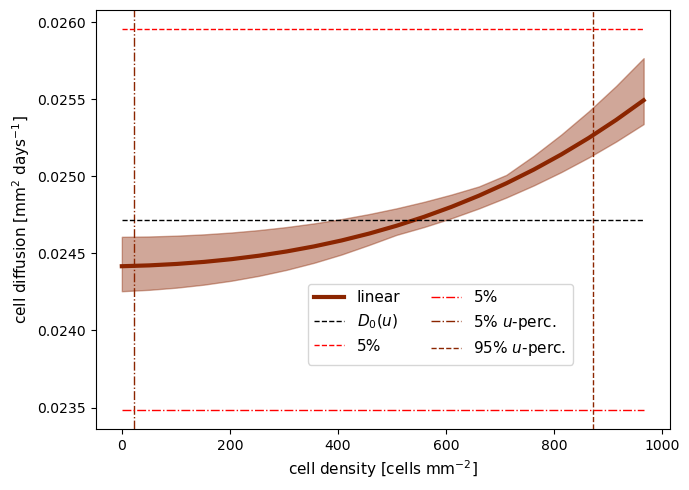

saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/grow/NNu64_ES2000_linear_dataGamma0_growth_plots_all.png


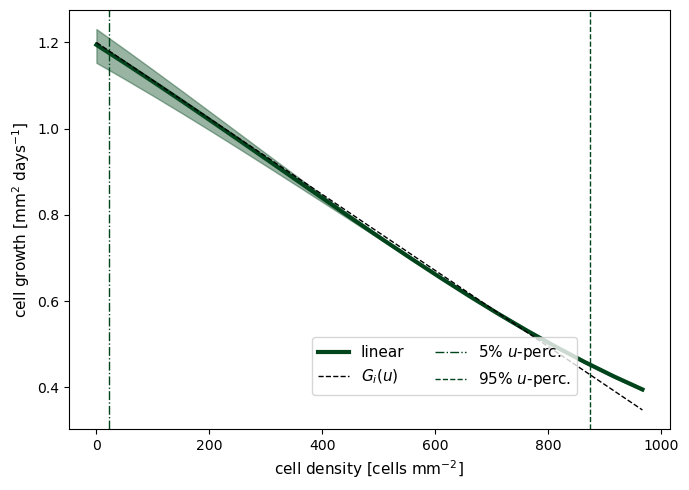

In [228]:
import sympy as sp
# --- Diffusion models ---
diffusion_models = {
    "const":     (lambda u, a: np.full_like(u, a), [0.02472]),
    "linear":    (lambda u, a, b: a + b * u,         [0.015, 0.06]),
    "quadratic": (lambda u, a, b: a + b * u**2,      [0.01, 0.044]),
    "exp":       (lambda u, a, b, c: a + b * (1 - sp.exp(-c * u)), [0.003, 0.095, 2.5])
}

# --- Growth models ---
growth_models = {
    "const":     (lambda u, a: np.full_like(u, a) / 2,          [1.3]),
    "linear":    (lambda u, a, b: (a + b * u) / 2,              [2.4, -3]),
    "quadratic": (lambda u, a, b: (a + b * u**2) / 2,           [2.1, -0.29]),
    "exp":       (lambda u, a, b, c: (a + b * (1 - sp.exp(-c * u))) / 2, [0.7, 1.3, -4]),
    "zero":      (lambda u, _: np.full_like(u, 0.0),            [0])
}

# --- Function dispatch ---
diff_func, theta_D = diffusion_models[diff_label]

def diffusion_func(u):
    return diff_func(u, *theta_D)

def growth_func(u):
    return grow_func(u, *theta_G)
D_sym_true = symbolic_from_function(diffusion_func)
D_sym_true_lst = [D_sym_true]


G_sym_true_lst = []
D_sym_true_lst = []
for grow_label in grow_labels:
    grow_func, theta_G = growth_models[grow_label]
    G_sym_true = symbolic_from_function(growth_func)
    G_sym_true_lst.append(G_sym_true)
    D_sym_true = symbolic_from_function(diffusion_func)
    D_sym_true_lst.append(D_sym_true)


err_up=5
err_low=5
errs = [err_up, err_low]
ES_idx = 0


ES = binn_ES_list[ES_idx]


# binn_models_dics_chosen_ES1000 = {
#     f"{d}": width_dict for d, width_dict in binn_models_by_ES[0].items() 
# }

binn_models_dics_chosen_ES = {
    f"{d}": width_dict for d, width_dict in binn_models_by_ES[ES_idx].items() 
}
# Combine both dicts now safely
binn_models_combined = {**binn_models_dics_chosen_ES}
                        # **binn_models_dics_chosen_ES2000}

labels = list(binn_models_combined.keys())

data_objs = [d for d in data_obj_dic.values()]

name_full_D = os.path.join(name_intro_D, f'NNu64_ES{binn_ES_list[0]}_{grow_label}_dataGamma{gamma}_diffusion_plots_all.png')
name_full_G = os.path.join(name_intro_G, f'NNu64_ES{binn_ES_list[0]}_{grow_label}_dataGamma{gamma}_growth_plots_all.png')
plot_eval_D_multi(binn_models_combined,
                 data_objs, 
                D_sym_true_lst, 
               D_colors, 
               labels, 
               Dnum=0,
               device="cpu", 
               num_bins=50, K=1700, 
               name=name_full_D,
               fill=True,
               legend_pos = (0.6,0.25),
               linestyles = ['-']*5,
               legend_ncols=2,
               legend_fontsize=11,
            #    xlim=(500,1000),
            #    ylim = (0.024,0.02),
               errs=errs)


plot_eval_G_multi(binn_models_combined,
                 data_objs, 
                G_sym_true_lst, 
               G_colors, 
               labels, 
               Gnum="i",
               device="cpu", 
               num_bins=50, K=1700, 
               name=name_full_G,
               fill=True,
               legend_pos = (0.625,0.15),
               linestyles = ['-']*5,
               legend_ncols=2,
                legend_fontsize=11,
               errs=None)




In [227]:
aaaa

NameError: name 'aaaa' is not defined

saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/grow/NNu64_linear_dataGamma0_growth_plots_linear.png


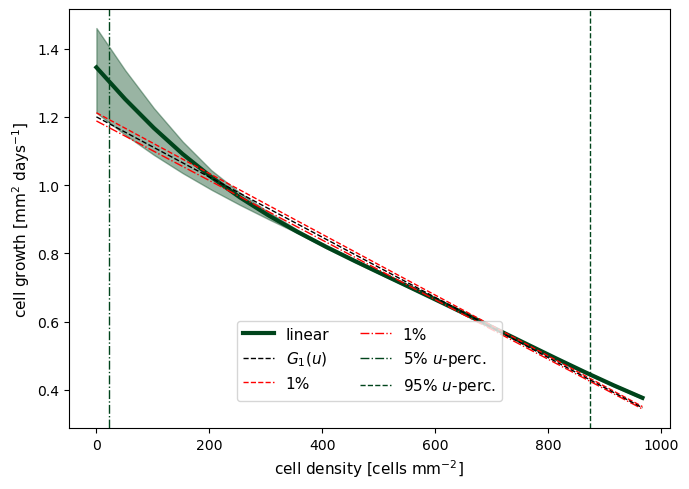

In [ ]:
errs_lst = [[1, 1], [5, 5], [5, 5], [5, 5]]
legend_pos_lst = [(0.5,0.16), (0.7,0.7), (0.785,0.75), (0.7,0.35)]
legend_ncols_lst = [2, 1, 1, 1]

for i, grow_label in enumerate(grow_labels):
    name_full_G = os.path.join(name_intro_G, f'NNu64_{grow_label}_dataGamma{gamma}_growth_plots_{grow_label}.png')

    plot_eval_G_multi({grow_label: binn_models_combined[grow_label]},
                    data_objs[i:i+1], 
                    G_sym_true_lst, 
                G_colors[i:i+1], 
                [labels[i]], 
                Gnum=i+1,
                device="cpu", 
                num_bins=50, K=1700, 
                name=name_full_G,
                fill=True,
                legend_pos = legend_pos_lst[i],
                linestyles = ['-']*5,
                legend_ncols=legend_ncols_lst[i],
                    legend_fontsize=11,
                errs=errs_lst[i])
                #xlim = [0,2500],
                #ylim=[0.62, 0.67])

saved plot: ../../pngs/1D/Case13/plot_varyD/diff_const/diff/NNu64_linear_dataGamma0_diff_plots_linear.png


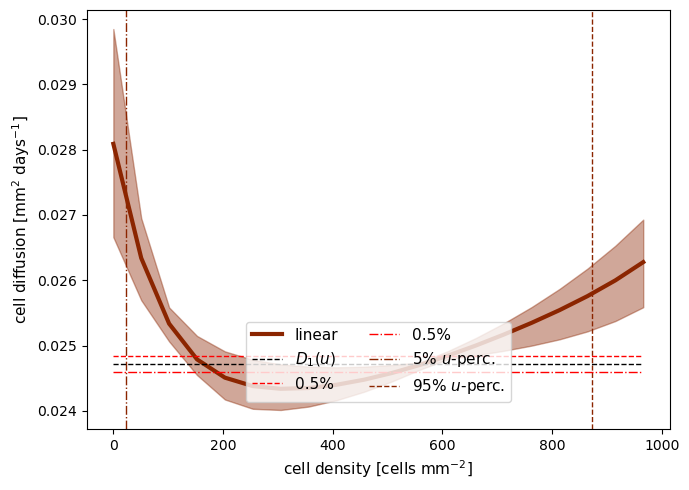

In [ ]:
errs_lst = [[0.5, 0.5], [5, 5], [3, 3], [1, 1]]
legend_pos_lst = [(0.5,0.16), (0.5,0.16), (0.5,0.3), (0.5,0.1)]
legend_ncols_lst = [2, 2, 2, 3]

for i, grow_label in enumerate(grow_labels):
    name_full_D = os.path.join(name_intro_D, f'NNu64_{grow_label}_dataGamma{gamma}_diff_plots_{grow_label}.png')



    plot_eval_D_multi({grow_label: binn_models_combined[grow_label]},
                    data_objs[i:i+1], 
                    D_sym_true_lst, 
                D_colors[i:i+1], 
                [labels[i]], 
                Dnum=i+1,
                device="cpu", 
                num_bins=50, K=1700, 
                name=name_full_D,
                fill=True,
                legend_pos = legend_pos_lst[i],
                linestyles = ['-']*5,
                legend_ncols=legend_ncols_lst[i],
                    legend_fontsize=11,
                errs=errs_lst[i])

In [ ]:
name_intro_D_gif = f"../../gifs/1D/Case13/plot_varyD/diff_{diff_label}/diff"

gif_path_D = os.path.join(
    name_intro_D_gif,
    f"NNu64_ES{binn_ES_list[0]}_{grow_label}_dataGamma{gamma}_D_mse.gif",
)

os.makedirs(name_intro_D_gif, exist_ok=True)

plot_settings_D = {
    'name': name_full_D,
    'fill': True,
    'line_width': 2,
    'legend': {
        'panel': 2,
        'loc': (0,1),
        'loc_upd': (0.2, 1),
        'fontsize': 13,
        'ncols': 1,
        'title': r"$N_D$"
    },
    'xaxis': {
        'min': 0,
        'max': 4e4,
        'break': 2e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": es_entries
}

# diff_gif_output = save_gif_running_min_MSE_diff_loss_broken_x_log(
#     # --- loss GIF inputs (as you had before) ---
#     models_dics_list=binn_models_by_ES,
#     plot_params=plot_params_D,
#     plot_settings=plot_settings_D,
#     out_path=gif_path_D,
#     stride=1,
#     dpi=100,
#     fps=1,

#     # --- real-space D(u) subplot inputs, mirroring plot_eval_D_multi ---
#     modelWrapper_dics=binn_models_combined,   # same as first arg in plot_eval_D_multi
#     dataobjs=data_objs,                       # same as data_objs
#     D_sym_true_lst=D_sym_true_lst,           # same
#     colors=D_colors,                         # same color list
#     labels=labels,                           # e.g. list(binn_models_combined.keys())
#     Dnum=0,                                  # same Dnum
#     K=1700,
#     num_bins=50,
#     realspace_fill=True,                     # corresponds to fill=True
#     legend_pos=(0.6, 0.25),
#     legend_ncols=2,
#     legend_fontsize=11,
#     linestyles_real=["-"] * len(labels),     # corresponds to linestyles=['-']*5
#     errs=errs,                               # same error bands as static plot

#     # optional: only set if you want to constrain D(u) axes
#     realspace_xlim=None,
#     realspace_ylim=None,
# )


In [ ]:
name_intro_G_gif = f"../../gifs/1D/Case13/plot_varyD/diff_{diff_label}/grow"

gif_path_G = os.path.join(
    name_intro_G_gif,
    f"NNu64_ES{binn_ES_list[0]}_{grow_label}_dataGamma{gamma}_G_mse.gif",
)

os.makedirs(name_intro_G_gif, exist_ok=True)

plot_settings_G = {
    'name': name_full_G,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (1,1),
        'loc_upd': (0.8, 1),
        'fontsize': 13,
        'ncols': 1,
        'title': r"$N_D$"
    },
    'xaxis': {
        'min': 0,
        'max': 4e4,
        'break': 2e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": es_entries
}
# grow_gif_output = save_gif_running_min_MSE_grow_loss_broken_x_log(
#     # --- loss GIF inputs (as you had before) ---
#     models_dics_list=binn_models_by_ES,
#     plot_params=plot_params_G,
#     plot_settings=plot_settings_G,
#     out_path=gif_path_G,
#     stride=1,
#     dpi=100,
#     fps=1,

#     # --- real-space D(u) subplot inputs, mirroring plot_eval_D_multi ---
#     modelWrapper_dics=binn_models_combined,   # same as first arg in plot_eval_D_multi
#     dataobjs=data_objs,                       # same as data_objs
#     G_sym_true_lst=G_sym_true_lst,           # same
#     colors=G_colors,                         # same color list
#     labels=labels,                           # e.g. list(binn_models_combined.keys())
#     Gnum=0,                                  # same Gnum
#     K=1700,
#     num_bins=50,
#     realspace_fill=True,                     # corresponds to fill=True
#     legend_pos=(0.6, 0.25),
#     legend_ncols=2,
#     legend_fontsize=11,
#     linestyles_real=["-"] * len(labels),     # corresponds to linestyles=['-']*5
#     errs=errs,                               # same error bands as static plot

#     # optional: only set if you want to constrain D(u) axes
#     realspace_xlim=None,
#     realspace_ylim=None,
# )


In [ ]:
#Image(grow_gif_output["out_path"])

/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/gif_DG_over_epochs.py:397: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1D.set_ylim(loss_ylim_diff)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/gif_DG_over_epochs.py:398: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2D.set_ylim(loss_ylim_diff)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/gif_DG_over_epochs.py:478: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1G.set_ylim(loss_ylim_grow)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case13/diff_const/../../Modules/helpers/performance/gif_DG_over_epochs.py:479: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.


KeyboardInterrupt: 

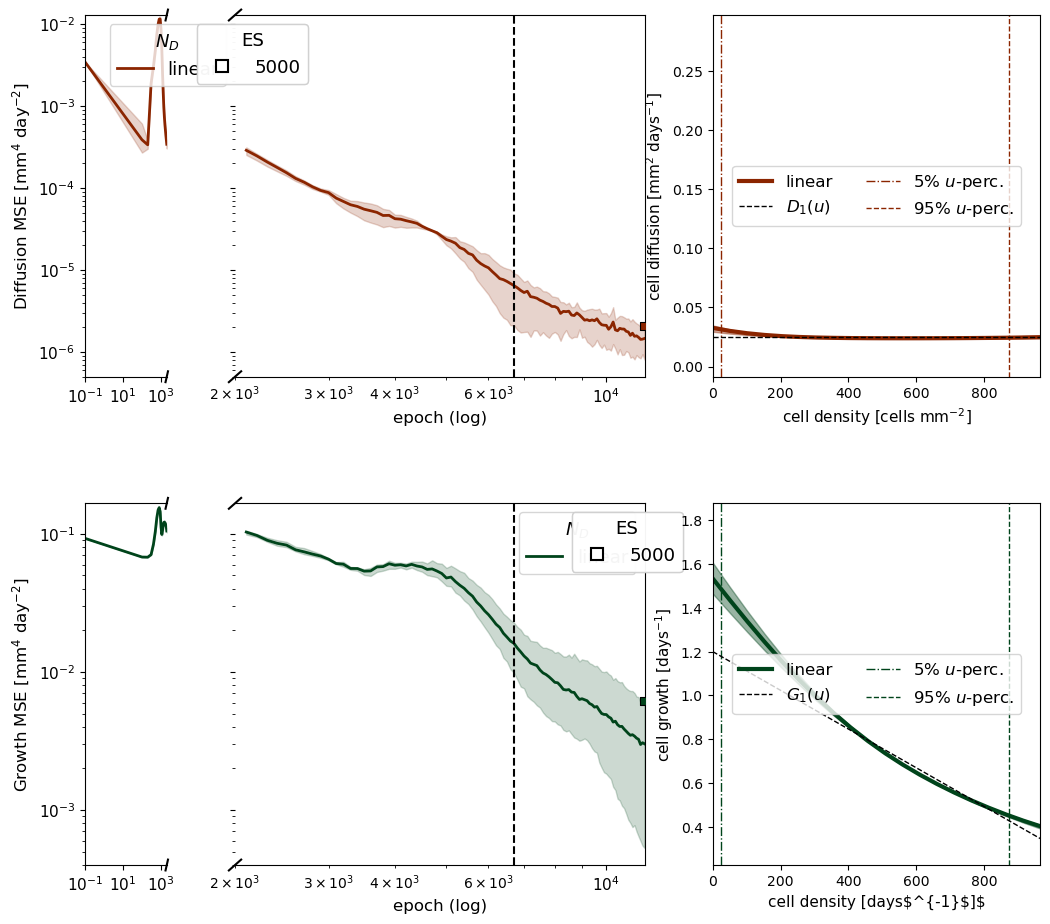

In [ ]:

combo_gif_output = save_gif_running_min_MSE_diff_and_grow_broken_x_log(
    diff_models_dics_list=binn_models_by_ES,
    grow_models_dics_list=binn_models_by_ES,
    diff_plot_params = plot_params_D,
    grow_plot_params = plot_params_G,
    diff_plot_settings = plot_settings_D,
    grow_plot_settings = plot_settings_G,
    diff_modelWrapper_dics=binn_models_combined,
    diff_dataobjs=data_objs,
    D_sym_true_lst=D_sym_true_lst,
    grow_modelWrapper_dics=binn_models_combined,
    grow_dataobjs=data_objs,
    G_sym_true_lst=G_sym_true_lst,
    D_colors=D_colors,
    G_colors=G_colors,
    labels=labels,
    out_path="diff_and_grow_two_rows.gif",
)


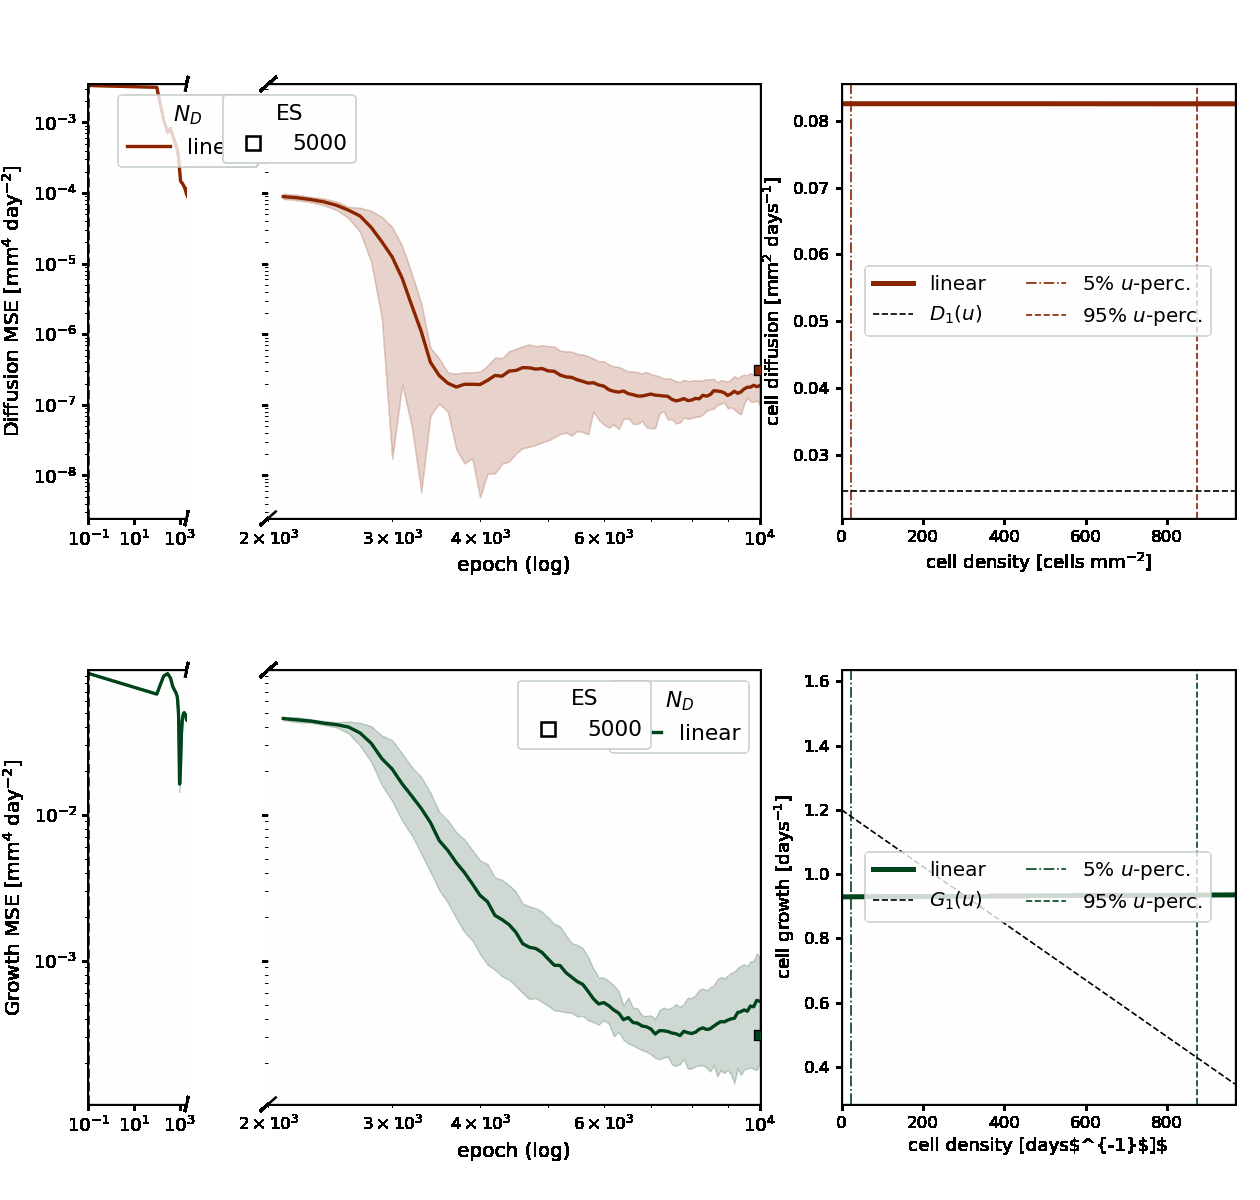

In [ ]:
Image("diff_and_grow_two_rows.gif")

Text(0.5, 0, 'Normalised density')

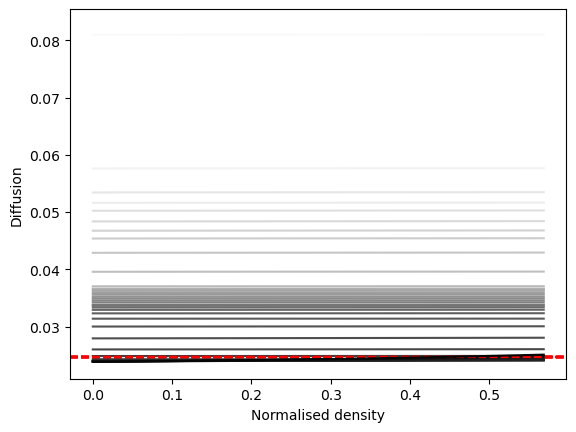

In [236]:
for i in range(40):
    # Convert predictions to numpy array
    nparr = np.array([j.detach().numpy() for j in binn_loaded.diffusion_preds[i]])
    density = np.array([j.detach().numpy() for j in binn_loaded.model.u_vals_torch])


    # Create a color that gets darker as i increases
    darkness = 1-i / 40

    color = (darkness, darkness, darkness)
    #print("i", i * 100, binn_loaded.frozen_switch_epoch)
    plt.axhline(0.02472, color='red', linestyle='--', label='True D value' if i == 0 else "")

    plt.plot(density,nparr, color=color)
    #plt.ylim(0.02, 0.03)
plt.ylabel('Diffusion')
plt.xlabel('Normalised density')


In [ ]:
def ic1(x, y):
    """
    2D analogue of the updated ic1(x):
    ic1(x) = 1/2 - 1/2 * cos(...) * cos(...)

    Returns:
        ic1(x,y) = 1/2 
                   - 1/2 * cos_x^2(...) * cos_y^2(...)
    """

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    Lx = np.max(x) - np.min(x)
    Ly = np.max(y) - np.min(y)

    X, Y = np.meshgrid(x, y, indexing='ij')

    cos_x = np.cos(2 * np.pi * (X - mean_x) / Lx)
    cos_y = np.cos(2 * np.pi * (Y - mean_y) / Ly)

    return 0.5 - 0.5 * (cos_x * cos_x) * (cos_y * cos_y)

In [ ]:
import numpy as np

def ic1(x, y, amplitude=1.0):
    """
    2D cosine-squared bump, like a Gaussian, centered at the geometric
    centre of the domain and decaying smoothly towards the boundaries.

    ic1(x, y) = amplitude * cos^2(π (x - xc) / Lx) * cos^2(π (y - yc) / Ly)

    where xc, yc are the geometric centres of the x, y domains.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # Geometric centre of the domain
    xc = 0.5 * (x.min() + x.max())
    yc = 0.5 * (y.min() + y.max())

    Lx = x.max() - x.min()
    Ly = y.max() - y.min()

    X, Y = np.meshgrid(x, y, indexing='ij')

    denomx = Lx * 0.5
    denomy = Ly * 0.5


    cos_x = np.cos(np.pi * (X - xc) / denomx)
    cos_y = np.cos(np.pi * (Y - yc) / denomy)

    return 1-   (cos_x**2) * (cos_y**2)


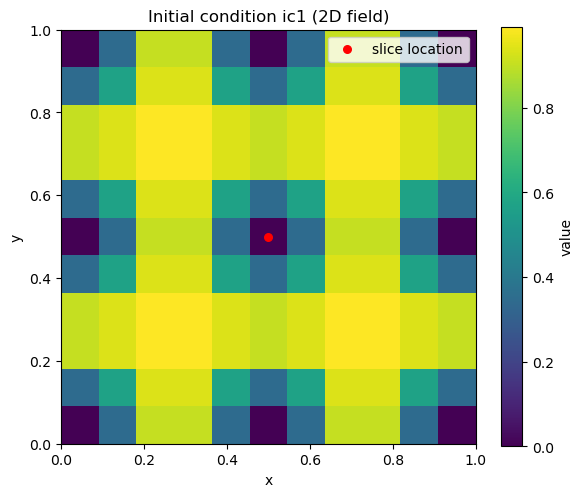

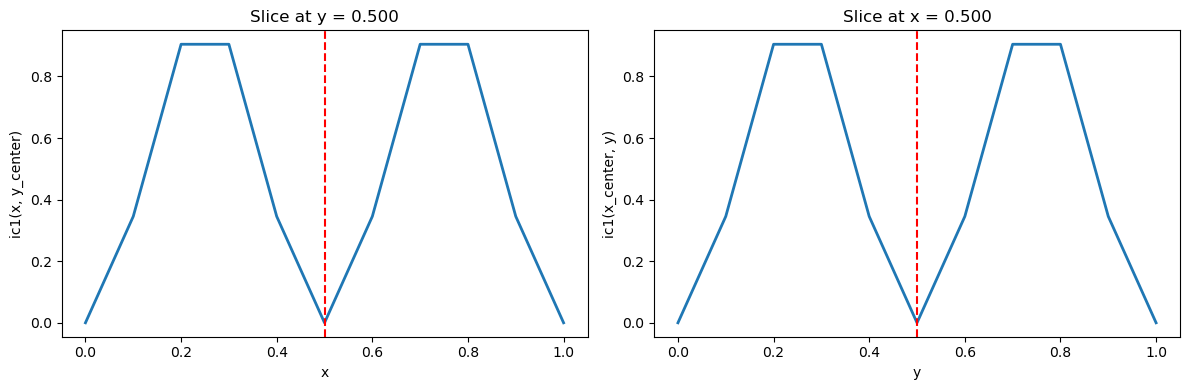

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ic1(ic_func, x=None, y=None):
    """
    Quick 2D visualization of an IC function ic_func(x, y),
    plus fixed-x and fixed-y slices through the geometric centre.
    """
    if x is None:
        x = np.linspace(0.0, 1.0, 200)
    if y is None:
        y = np.linspace(0.0, 1.0, 200)

    Z = ic_func(x, y)  # shape (Nx, Ny)

    # Centre indices
    ix = len(x) // 2   # center x index
    iy = len(y) // 2   # center y index

    x_center = x[ix]
    y_center = y[iy]

    # Extract slices
    slice_y_fixed = Z[:, iy*0]   # Z(x, y_center)
    slice_x_fixed = Z[ix, :]   # Z(x_center, y)

    # ---- Plot 2D map ----
    plt.figure(figsize=(6, 5))
    im = plt.imshow(
        Z.T,
        origin='lower',
        extent=(x.min(), x.max(), y.min(), y.max()),
        aspect='equal'
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Initial condition ic1 (2D field)")
    plt.colorbar(im, label="value")
    plt.scatter([x_center], [y_center], color='red', s=30, label="slice location")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Plot slices ----
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # slice at fixed y
    ax[0].plot(x, slice_y_fixed, lw=2)
    ax[0].axvline(x_center, color='r', ls='--')
    ax[0].set_title(f"Slice at y = {y_center:.3f}")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("ic1(x, y_center)")

    # slice at fixed x
    ax[1].plot(y, slice_x_fixed, lw=2)
    ax[1].axvline(y_center, color='r', ls='--')
    ax[1].set_title(f"Slice at x = {x_center:.3f}")
    ax[1].set_xlabel("y")
    ax[1].set_ylabel("ic1(x_center, y)")

    plt.tight_layout()
    plt.show()

plot_ic1(ic1, x=data_obj.x1, y=data_obj.x2)